# Customer Segmentation
Analysis
Problem Statement
A retail company has a large customer base with different purchasing behaviors, spending patterns,
and product preferences. The management wants to understand customer groups more effectively so
that they can create targeted marketing campaigns and improve customer satisfaction. Since analyzing
customer data manually is difficult due to the large volume of records, the company plans to use data
mining techniques to identify meaningful customer segments and support better business
decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = {
    "Customer_ID": range(1,101),

    "Age": np.random.randint(18,70,100),

    "Annual_Income": np.random.randint(
        20000,150000,100
    ),

    "Spending_Score": np.random.randint(
        1,100,100
    ),

    "Total_Purchases": np.random.randint(
        1,80,100
    )
}


df = pd.DataFrame(data)

df.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases
0,1,33,108002,49,77
1,2,39,111042,54,53
2,3,35,88522,1,18
3,4,48,77351,45,35
4,5,56,83838,40,28


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Customer_ID      100 non-null    int64
 1   Age              100 non-null    int32
 2   Annual_Income    100 non-null    int32
 3   Spending_Score   100 non-null    int32
 4   Total_Purchases  100 non-null    int32
dtypes: int32(4), int64(1)
memory usage: 2.5 KB


In [4]:
df.describe()

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases
count,100.000000,100.00000,100.00000,100.000000,100.000000
mean,50.500000,44.64000,84040.31000,48.570000,41.180000
std,29.011492,15.27229,38748.21146,27.440755,21.170964
min,1.000000,18.00000,20547.00000,1.000000,2.000000
25%,25.750000,32.75000,51689.25000,30.500000,28.000000
50%,50.500000,45.00000,77271.50000,45.000000,40.000000
75%,75.250000,56.50000,115372.75000,73.000000,59.250000
max,100.000000,69.00000,149798.00000,98.000000,77.000000


Clean and Preprocess Dataset

In [5]:
df.isnull().sum()

Customer_ID        0
Age                0
Annual_Income      0
Spending_Score     0
Total_Purchases    0
dtype: int64

In [6]:
customer_id = df["Customer_ID"]

df2 = df.drop(
    "Customer_ID",
    axis=1
)

df2.head()

,Age,Annual_Income,Spending_Score,Total_Purchases
0,33,108002,49,77
1,39,111042,54,53
2,35,88522,1,18
3,48,77351,45,35
4,56,83838,40,28


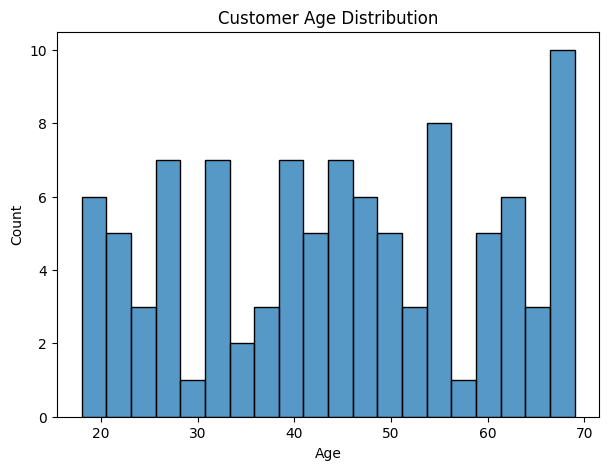

In [7]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Age"],
    bins=20
)

plt.title(
    "Customer Age Distribution"
)

plt.show()

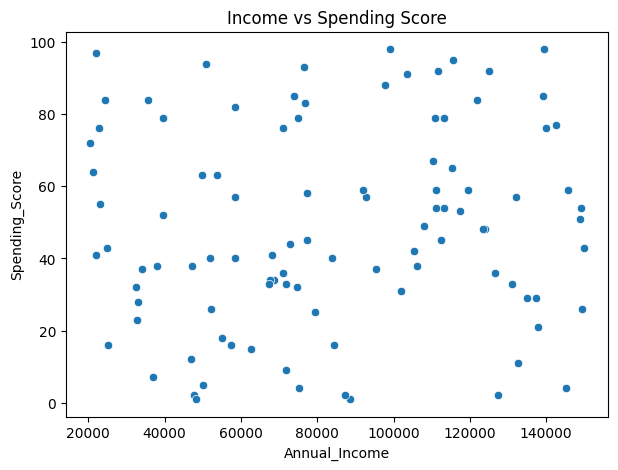

In [8]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Annual_Income"],
    y=df["Spending_Score"]
)

plt.title(
    "Income vs Spending Score"
)

plt.show()

In [10]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df2)

scaled_data[:5]

array([[-0.76600435,  0.62151009,  0.01574907,  1.70046368],
       [-0.37115674,  0.70036057,  0.19887774,  0.56112453],
       [-0.63438848,  0.11624454, -1.74228619, -1.10041173],
       [ 0.22111466, -0.17350503, -0.13075387, -0.29337983],
       [ 0.74757812, -0.00524745, -0.31388254, -0.62568708]])

Customer Segmentation Technique

K-Means Clustering

Elbow Method

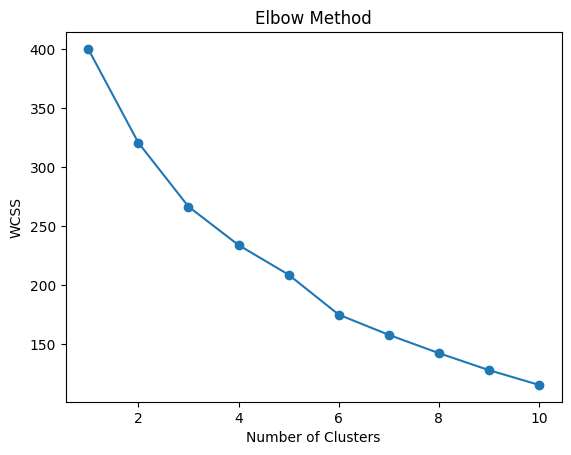

In [11]:
wcss=[]


for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)



plt.plot(
    range(1,11),
    wcss,
    marker="o"
)


plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "WCSS"
)

plt.title(
    "Elbow Method"
)

plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)


clusters = kmeans.fit_predict(
    scaled_data
)


df["Segment"] = clusters


df.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases,Segment
0,1,33,108002,49,77,0
1,2,39,111042,54,53,0
2,3,35,88522,1,18,2
3,4,48,77351,45,35,2
4,5,56,83838,40,28,3


Check Accuracy Quality

In [13]:
score = silhouette_score(
    scaled_data,
    clusters
)

print(
    "Silhouette Score:",
    score
)

Silhouette Score: 0.18230742681367273


Analyze Customer Groups

In [14]:
df["Segment"].value_counts()

Segment
2    36
3    22
0    21
1    21
Name: count, dtype: int64

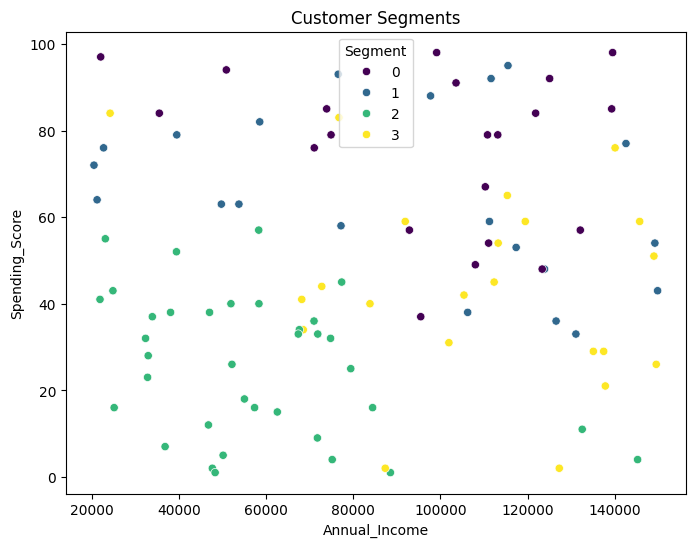

In [15]:
plt.figure(figsize=(8,6))


sns.scatterplot(
    x=df["Annual_Income"],
    y=df["Spending_Score"],
    hue=df["Segment"],
    palette="viridis"
)


plt.title(
    "Customer Segments"
)


plt.show()

In [16]:
segment_analysis = df.groupby(
    "Segment"
).mean()


segment_analysis

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases
Segment,,,,,
0,50.428571,31.857143,97797.380952,75.714286,52.761905
1,55.476190,61.428571,90598.285714,65.047619,54.761905
2,42.972222,42.888889,57909.388889,25.694444,40.972222
3,58.136364,43.681818,107408.363636,44.363636,17.500000


Conclusion

* Customer segmentation helps in grouping customers based on similar characteristics and behavior.
* It makes it easier to understand customer needs and purchasing patterns.
* The analysis supports better marketing strategies and business planning.
* It helps companies make informed decisions using customer data.
* Overall, customer segmentation is an effective technique for improving customer satisfaction and business performance.